<a href="https://colab.research.google.com/github/SruthiGS-Gito/Case-Study---Assignment-MLAI-B3/blob/main/adult_dataset_torchVStensorflow.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

## ⚛ Importing Libraries

In [26]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.preprocessing import LabelEncoder
from sklearn.model_selection import train_test_split

from sklearn.preprocessing import StandardScaler
from sklearn.metrics import accuracy_score

import tensorflow as tf
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Dense

import torch
import torch.nn as nn
import torch.optim as optim

import time

## ⚛ Dataset loading

In [27]:
df_adult = pd.read_csv("/content/drive/MyDrive/AI ML/ICT_AI_ML/student_manager/data/adult_dataset.csv")
df_adult.head()

,age,workclass,fnlwgt,education,education-num,marital-status,occupation,relationship,race,sex,capital-gain,capital-loss,hours-per-week,native-country,income
0,39.0,State-gov,77516,Bachelors,13,Never-married,Adm-clerical,Not-in-family,White,Male,2174,0,40.0,NaN,<=50K
1,50.0,Self-emp-not-inc,83311,Bachelors,13,Married-civ-spouse,Exec-managerial,Husband,White,Male,0,0,13.0,United-States,<=50K
2,38.0,Private,215646,HS-grad,9,Divorced,Handlers-cleaners,Not-in-family,White,Male,0,0,40.0,United-States,<=50K
3,53.0,Private,234721,11th,7,Married-civ-spouse,Handlers-cleaners,Husband,Black,Male,0,0,40.0,United-States,<=50K
4,28.0,Private,338409,Bachelors,13,Married-civ-spouse,Prof-specialty,Wife,Black,Female,0,0,40.0,Cuba,<=50K


## ⚛ EDA

In [28]:
df_adult.shape

(48842, 15)

In [29]:
df_adult.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 48842 entries, 0 to 48841
Data columns (total 15 columns):
 #   Column          Non-Null Count  Dtype  
---  ------          --------------  -----  
 0   age             46400 non-null  float64
 1   workclass       45480 non-null  object 
 2   fnlwgt          48842 non-null  int64  
 3   education       48842 non-null  object 
 4   education-num   48842 non-null  int64  
 5   marital-status  48842 non-null  object 
 6   occupation      45485 non-null  object 
 7   relationship    48842 non-null  object 
 8   race            48842 non-null  object 
 9   sex             48842 non-null  object 
 10  capital-gain    48842 non-null  int64  
 11  capital-loss    48842 non-null  int64  
 12  hours-per-week  46400 non-null  float64
 13  native-country  46137 non-null  object 
 14  income          48842 non-null  object 
dtypes: float64(2), int64(4), object(9)
memory usage: 5.6+ MB


In [30]:
df_adult.describe()

,age,fnlwgt,education-num,capital-gain,capital-loss,hours-per-week
count,46400.000000,4.884200e+04,48842.000000,48842.000000,48842.000000,46400.000000
mean,38.679116,1.896641e+05,10.078089,1079.067626,87.502314,40.448599
std,13.952954,1.056040e+05,2.570973,7452.019058,403.004552,12.646992
min,17.000000,1.228500e+04,1.000000,0.000000,0.000000,1.000000
25%,28.000000,1.175505e+05,9.000000,0.000000,0.000000,40.000000
50%,37.000000,1.781445e+05,10.000000,0.000000,0.000000,40.000000
75%,48.000000,2.376420e+05,12.000000,0.000000,0.000000,45.000000
max,255.000000,1.490400e+06,16.000000,99999.000000,4356.000000,250.000000


In [31]:
df_adult.isnull().sum()

,0
age,2442
workclass,3362
fnlwgt,0
education,0
education-num,0
marital-status,0
occupation,3357
relationship,0
race,0
sex,0


In [32]:
df_adult.duplicated().sum()

np.int64(16)

In [33]:
df_adult["income"].value_counts()

,count
income,
<=50K,24720
<=50K.,12435
>50K,7841
>50K.,3846


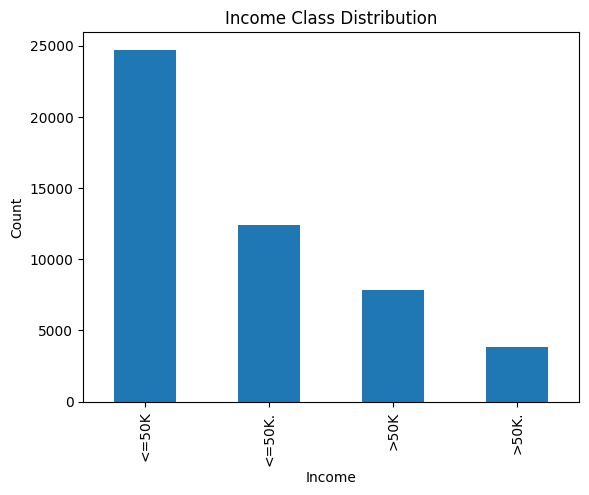

In [34]:
# Plot the target class distribution
df_adult["income"].value_counts().plot(kind="bar")
plt.title("Income Class Distribution")
plt.xlabel("Income")
plt.ylabel("Count")
plt.show()

## ⚛ Data Preprocessing

### ▶ Missing Value Handling

In [35]:
# Fill missing values in numerical columns with median
df_adult["age"].fillna(df_adult["age"].median(), inplace=True)
df_adult["hours-per-week"].fillna(df_adult["hours-per-week"].median(), inplace=True)

/tmp/ipykernel_2191/2966459840.py:2: FutureWarning: A value is trying to be set on a copy of a DataFrame or Series through chained assignment using an inplace method.
The behavior will change in pandas 3.0. This inplace method will never work because the intermediate object on which we are setting values always behaves as a copy.

For example, when doing 'df[col].method(value, inplace=True)', try using 'df.method({col: value}, inplace=True)' or df[col] = df[col].method(value) instead, to perform the operation inplace on the original object.


  df_adult["age"].fillna(df_adult["age"].median(), inplace=True)
/tmp/ipykernel_2191/2966459840.py:3: FutureWarning: A value is trying to be set on a copy of a DataFrame or Series through chained assignment using an inplace method.
The behavior will change in pandas 3.0. This inplace method will never work because the intermediate object on which we are setting values always behaves as a copy.

For example, when doing 'df[col].method(value, inplac

In [36]:
# Fill missing values in categorical columns with mode
df_adult["workclass"].fillna(df_adult["workclass"].mode()[0], inplace=True)
df_adult["occupation"].fillna(df_adult["occupation"].mode()[0], inplace=True)
df_adult["native-country"].fillna(df_adult["native-country"].mode()[0], inplace=True)

/tmp/ipykernel_2191/4139590016.py:2: FutureWarning: A value is trying to be set on a copy of a DataFrame or Series through chained assignment using an inplace method.
The behavior will change in pandas 3.0. This inplace method will never work because the intermediate object on which we are setting values always behaves as a copy.

For example, when doing 'df[col].method(value, inplace=True)', try using 'df.method({col: value}, inplace=True)' or df[col] = df[col].method(value) instead, to perform the operation inplace on the original object.


  df_adult["workclass"].fillna(df_adult["workclass"].mode()[0], inplace=True)
/tmp/ipykernel_2191/4139590016.py:3: FutureWarning: A value is trying to be set on a copy of a DataFrame or Series through chained assignment using an inplace method.
The behavior will change in pandas 3.0. This inplace method will never work because the intermediate object on which we are setting values always behaves as a copy.

For example, when doing 'df[col].method(

In [37]:
# To verify it
df_adult.isnull().sum()

,0
age,0
workclass,0
fnlwgt,0
education,0
education-num,0
marital-status,0
occupation,0
relationship,0
race,0
sex,0


In [38]:
le = LabelEncoder()
for column in df_adult.columns:
    if df_adult[column].dtype == "object":
        df_adult[column] = le.fit_transform(df_adult[column])
df_adult.head()

,age,workclass,fnlwgt,education,education-num,marital-status,occupation,relationship,race,sex,capital-gain,capital-loss,hours-per-week,native-country,income
0,39.0,7,77516,9,13,4,1,1,4,1,2174,0,40.0,39,0
1,50.0,6,83311,9,13,2,4,0,4,1,0,0,13.0,39,0
2,38.0,4,215646,11,9,0,6,1,4,1,0,0,40.0,39,0
3,53.0,4,234721,1,7,2,6,0,2,1,0,0,40.0,39,0
4,28.0,4,338409,9,13,2,10,5,2,0,0,0,40.0,5,0


### ▶ Data Spliting

In [39]:
X = df_adult.drop("income", axis=1)
y = df_adult["income"]

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

In [40]:
X_train.shape

(39073, 14)

In [41]:
X_test.shape

(9769, 14)

### ▶ Scaling

In [42]:
scaler = StandardScaler()
X_train = scaler.fit_transform(X_train)
X_test = scaler.transform(X_test)

## ⚛ Tensorflow

In [43]:
# Building the Artificial Neural Network
model = Sequential([
    Dense(64, activation="relu", input_shape=(14,)),    # First hidden layer with 64 neurons
    Dense(32, activation="relu"),                       # Second hidden layer with 32 neurons
    Dense(1, activation="sigmoid")                      # Output layer
])

/usr/local/lib/python3.12/dist-packages/keras/src/layers/core/dense.py:106: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


In [44]:
# Configuring the model for training
model.compile(
    optimizer="adam",
    loss="binary_crossentropy",
    metrics=["accuracy"]
)

In [45]:
# Recording the training start time
start_time = time.perf_counter()

history = model.fit(
    X_train,
    y_train,
    epochs=50,
    batch_size=32,
    validation_split=0.2,
    verbose=0
)

# Recording the training end time
end_time = time.perf_counter()
print(f"Training Time : {end_time-start_time:.4f} seconds")

Training Time : 129.1898 seconds


In [46]:
# Evaluating the trained model
loss, accuracy = model.evaluate(
    X_test,
    y_test,
    verbose=0
)
print("Loss :", loss)
print("Accuracy :", accuracy)

Loss : -32913046.0
Accuracy : 0.34711843729019165


## ⚛ PyTorch

In [49]:
# Convert NumPy arrays into PyTorch tensors
X_train_tensor = torch.FloatTensor(X_train)
X_test_tensor = torch.FloatTensor(X_test)
y_train_tensor = torch.FloatTensor(y_train.values.reshape(-1,1))
y_test_tensor = torch.FloatTensor(y_test.values.reshape(-1,1))

In [50]:
# Artificial Neural Network
class ANN(nn.Module):
    def __init__(self):
        super().__init__()
        self.network = nn.Sequential(
            nn.Linear(14,64),
            nn.ReLU(),

            nn.Linear(64,32),
            nn.ReLU(),

            nn.Linear(32,1),
            nn.Sigmoid()
        )
    def forward(self,x):
        return self.network(x)

In [51]:
# Creating an instance of the ANN model
model = ANN()

In [52]:
# Binary Cross Entropy loss function
criterion = nn.BCELoss()

In [53]:
# Adam optimizer
optimizer = optim.Adam(
    model.parameters(),
    lr=0.001
)

In [54]:
start_time = time.perf_counter()
epochs = 50

for epoch in range(epochs):
    outputs = model(X_train_tensor)     # forward propagation

    loss = criterion(outputs, y_train_tensor)

    optimizer.zero_grad()

    loss.backward()                     # Backpropagation

    optimizer.step()

    if (epoch+1)%10 == 0:
        print(f"Epoch {epoch+1}: Loss = {loss.item():.4f}")

end_time = time.perf_counter()
print(f"Training Time : {end_time-start_time:.4f} seconds")

RuntimeError: all elements of target should be between 0 and 1

In [55]:
y_train.unique()

array([1, 2, 0, 3])